Vamos importar as bibliotecas fundamentais

In [1]:
import numpy as np
import pandas as pd
import spacy 
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import imageio.v2 as imageio
import os

Vamos dar uma olhada pra ver se a gpu está rodando no kernel do Colab
Se tiver certinho, vamos continuar

In [2]:
!nvidia-smi

Thu May 21 13:09:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Vamos instalar o Spacy com o português

In [2]:
%%capture
!python -m spacy download pt_core_news_lg

### Testando o Wordcloud

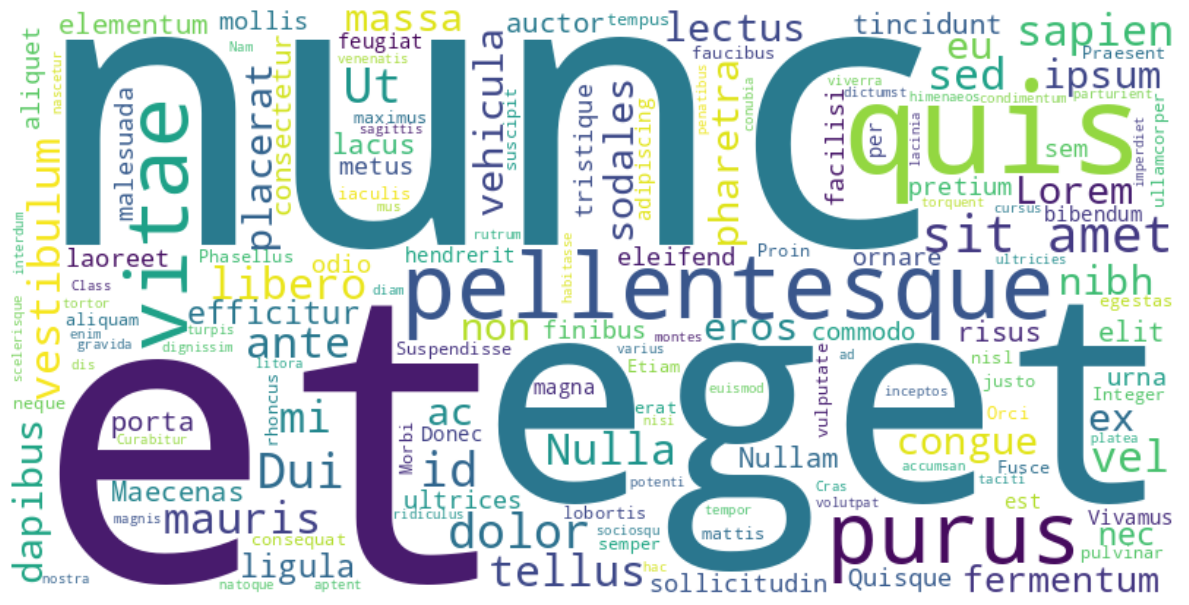

In [3]:
texto = """
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Maecenas tincidunt libero ac vehicula vehicula. Ut non volutpat risus, vitae porta mi. Nunc bibendum feugiat libero a porta. Vivamus at tortor eu eros auctor placerat pharetra id risus. Sed in magna eget eros elementum vehicula. Donec quis elementum ante. Donec ac est vestibulum, pharetra ex non, gravida lacus. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Nullam sollicitudin risus ante, quis hendrerit mi feugiat vitae.

Quisque sit amet finibus purus. Curabitur elementum sem ut libero euismod pretium. Vivamus vitae dignissim lectus. Suspendisse hendrerit, metus sit amet pulvinar venenatis, ante odio accumsan nibh, quis lobortis massa justo eu nunc. Morbi ut ullamcorper sapien. Duis dapibus sodales nunc id bibendum. Nullam mauris purus, congue vel diam semper, ornare fermentum purus. Pellentesque ullamcorper massa lorem, efficitur eleifend lorem efficitur eu. Nam sodales dolor vitae ex ultricies, quis pulvinar eros sollicitudin. Praesent aliquet purus in metus tristique condimentum. Vestibulum aliquet mollis lectus, ac sodales purus lobortis et. Nullam aliquam laoreet turpis, pretium rhoncus lectus pellentesque et. Cras et iaculis mi. Quisque sapien elit, ornare non ligula at, maximus congue ligula. Lorem ipsum dolor sit amet, consectetur adipiscing elit.

Ut facilisis, ligula eu egestas mollis, sem massa pharetra sem, et placerat dui dolor quis eros. Integer eget libero faucibus tellus consequat pellentesque eget at ipsum. Nunc nec mattis erat, sed tristique nibh. Nunc sed pellentesque neque. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Integer interdum eget nunc non commodo. Duis auctor mauris eget nulla consectetur sagittis et eget mauris. Maecenas ac mattis est. Duis lacinia vitae lectus quis tempus. Vestibulum in sapien quis nisl tempor suscipit. Suspendisse potenti.

Maecenas vehicula congue nunc laoreet consequat. Sed massa ex, placerat laoreet sapien sit amet, maximus egestas enim. Pellentesque pretium commodo mi. Quisque dapibus eget urna et malesuada. Etiam viverra purus vel urna vulputate, id semper dui finibus. Pellentesque nec ex a dolor eleifend ultrices. In hac habitasse platea dictumst. Phasellus tincidunt tellus dapibus ipsum fermentum, sed placerat mauris ultrices. Nulla pellentesque et nibh a ornare. Nulla facilisi. Phasellus vitae purus vel erat vestibulum vestibulum. Ut vel ultrices odio.

Proin dapibus tellus ut porta rutrum. Praesent pellentesque fermentum ligula a faucibus. Proin mi mauris, tincidunt at vulputate fermentum, sollicitudin et tellus. Duis eget magna lacus. Etiam vel tellus sit amet lacus rhoncus commodo. Fusce a orci quis nisi sodales eleifend. Nulla id suscipit nisl. Aliquam malesuada ante ante, nec aliquet nibh scelerisque vitae. In pharetra imperdiet dolor nec tristique. Morbi congue, nulla finibus mollis cursus, odio libero facilisis sapien, id malesuada urna neque sit amet metus. Fusce auctor tempus nunc, iaculis efficitur justo efficitur id.

"""

wc = WordCloud(width=800, height = 400, background_color='white').generate(texto)
plt.figure(figsize=(12,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

### Vamos agora importar a base de dados

Os textos das atas eu extraí de [outro projeto](https://github.com/sdavibl/Web-Scraping-nas-Atas-do-COPOM) que eu tenho

In [16]:
dados = pd.read_csv("atas_do_copom.csv")
dados = dados[["data", "texto"]]
dados

,data,texto
0,05/05/2026,"1. O ambiente externo permanece incerto, em fu..."
1,24/03/2026,"1. O ambiente externo tornou-se mais incerto, ..."
2,03/02/2026,1. O ambiente externo ainda se mantém incerto ...
3,16/12/2025,1. O ambiente externo ainda se mantém incerto ...
4,11/11/2025,1. O ambiente externo ainda se mantém incerto ...
5,23/09/2025,1. O ambiente externo se mantém incerto em fun...
6,05/08/2025,1. O ambiente externo está mais adverso e ince...
7,24/06/2025,1. O ambiente externo mantém-se adverso e part...
8,13/05/2025,1. O ambiente externo mostra-se adverso e part...
9,25/03/2025,1. O ambiente externo permanece desafiador em ...


Temos agora nossa base importada direitinho. O que vamos fazer é apenas textar o wordcloud em cima de todos os textos que extraímos.

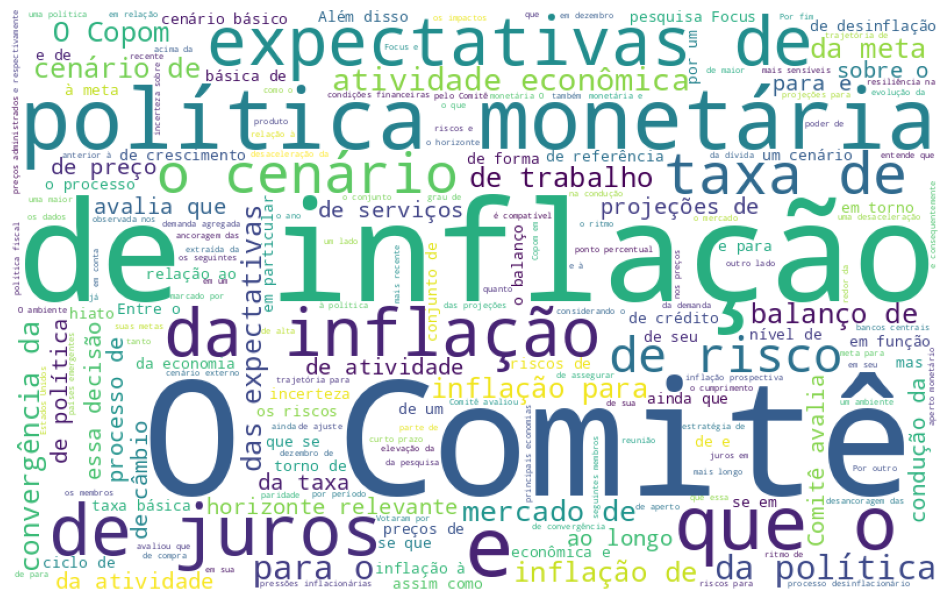

In [27]:
texto_teste = ' '.join(dados['texto'].dropna().astype(str))

wc = WordCloud(width=800, height=500, background_color='white').generate(texto_teste)

plt.figure(figsize=(12,8))
plt.imshow(wc)
plt.axis('off')
plt.show()

### Vamos programar o lemmetizador

Como podemos ver na imagem, tivemos muitas stopwords e palavras que não serão muito úteis em uma análise mais fundamentada, como "O Comitê", "inflação", "inflação de", "de juros", etc...e outras _stopwords_, que é o nome de damos a preposições, conjunções, artigos, etc... (de, o, para, onde, da, assim, etc...)

Imediatamente abaixo, iremos configurar a função de lemmetizar e testá-la. Além disso, iremos retornar as stopwords em português.

A ideia de lemmetizar é facilitar o aprendizado da máquina. Imagine o verbo "roer". Ele pode aparecer em uma sentença nas formas: roeu, roemos, roído, roeram, roera, etc...Isso tornaria o aprendizado, através da criação da matriz, praticamente impossível de ser realizada. Então todas essas variações, com o mesmo sentido semântico, serão reduzidos pela lemmetização a "roer". 

Há outras formas de fazer esse processo de diminuir a dimensionalidade para a máquina, que seria o stemmer, usando por exemplo a biblioteca NLTK ou Snowball. Mas elas se resumem a pegar o núcleo da palavra: "roe" por exemplo, que não é o que eu estou interessado.

In [ ]:
nlp = spacy.load("pt_core_news_lg")
def lemmetizar(string):
    string = re.sub("[^A-zÀ-ú0-9]+", ' ', string).lower() # pegar apenas palavras inteiras com acentuação ou nasalização
    doc = nlp(string)
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

lemmetizar("O rato roeu a roupa do rei de roma.")

'rato roeu roupa rei Roma'

Agora, iremos refazer o wordcloud, mas sem as stopwords e outras palavras como "Comitê", para visualizarmos melhor. Antes disso: gostaria de demonstrar as stopwords que o Spacy em Português conhece.

In [33]:
nlp.Defaults.stop_words

{'a',
 'acerca',
 'ademais',
 'adeus',
 'agora',
 'ainda',
 'algo',
 'algumas',
 'alguns',
 'ali',
 'além',
 'ambas',
 'ambos',
 'antes',
 'ao',
 'aos',
 'apenas',
 'apoia',
 'apoio',
 'apontar',
 'após',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aqui',
 'aquilo',
 'as',
 'assim',
 'através',
 'atrás',
 'até',
 'aí',
 'baixo',
 'bastante',
 'bem',
 'boa',
 'bom',
 'breve',
 'cada',
 'caminho',
 'catorze',
 'cedo',
 'cento',
 'certamente',
 'certeza',
 'cima',
 'cinco',
 'coisa',
 'com',
 'como',
 'comprida',
 'comprido',
 'conhecida',
 'conhecido',
 'conselho',
 'contra',
 'contudo',
 'corrente',
 'cuja',
 'cujo',
 'custa',
 'cá',
 'da',
 'daquela',
 'daquele',
 'dar',
 'das',
 'de',
 'debaixo',
 'demais',
 'dentro',
 'depois',
 'des',
 'desde',
 'dessa',
 'desse',
 'desta',
 'deste',
 'deve',
 'devem',
 'deverá',
 'dez',
 'dezanove',
 'dezasseis',
 'dezassete',
 'dezoito',
 'diante',
 'direita',
 'disso',
 'diz',
 'dizem',
 'dizer',
 'do',
 'dois',
 'dos',
 'doze',
 'duas',
 'dá

Vamos remover essas stopwords e outras que escolhemos para ver melhor o Wordcloud

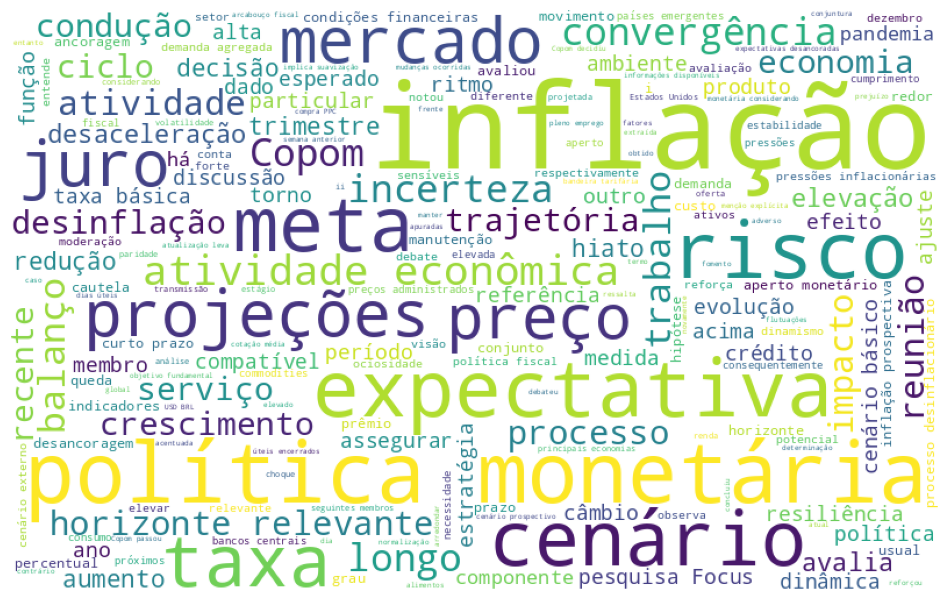

In [ ]:
stopw = nlp.Defaults.stop_words.union(["Comitê"])

wc = WordCloud(stopwords=stopw, width=800, height=500, background_color='white').generate(texto_teste)

plt.figure(figsize=(12,8))
plt.imshow(wc)
plt.axis('off')
plt.show()

Podemos ver que os termos mais presentes envolvem a inflação, as expectativas e as projeções. 

E se ampliarmos mais ainda e retirarmos mais alguns termos? É evidente que "política monetária" e "inflação" estarão demasiadamente presentes.

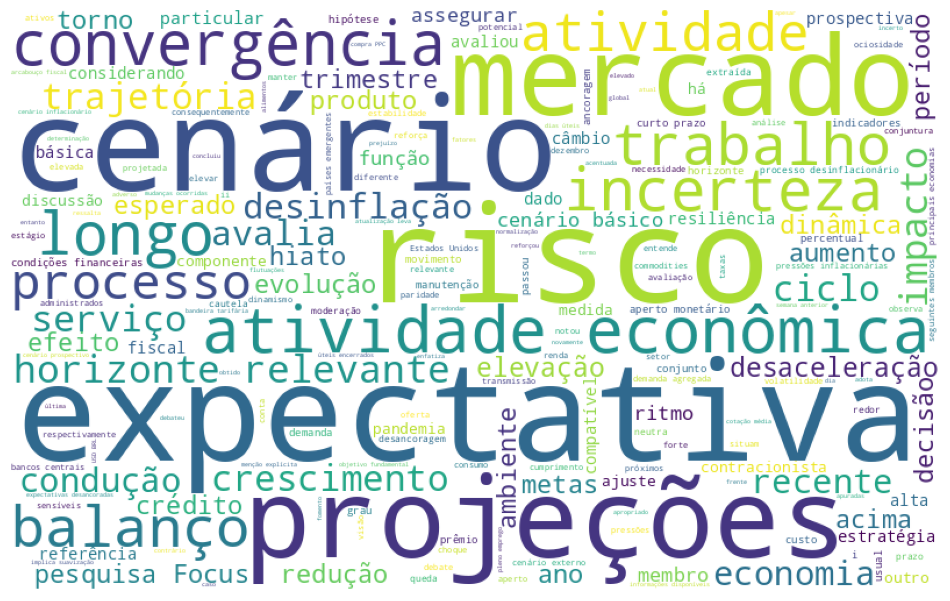

In [ ]:
wc = WordCloud(stopwords=stopw, width=800, height=500, background_color='white').generate(texto_teste)

plt.figure(figsize=(12,8))
plt.imshow(wc)
plt.axis('off')
plt.show()

### Analisando a mudança de conduta após a posse de Gabriel Galípolo

O que vamos fazer agora é fatiar esses textos em 2: antes da posse de Gabriel Galípolo em 01/01/2025 como presidente do Banco Central, e depois dessa data. Vamos analisar se há diferença visível nos WordClouds

Text(0.5, 1.0, 'Depois de Galípolo')

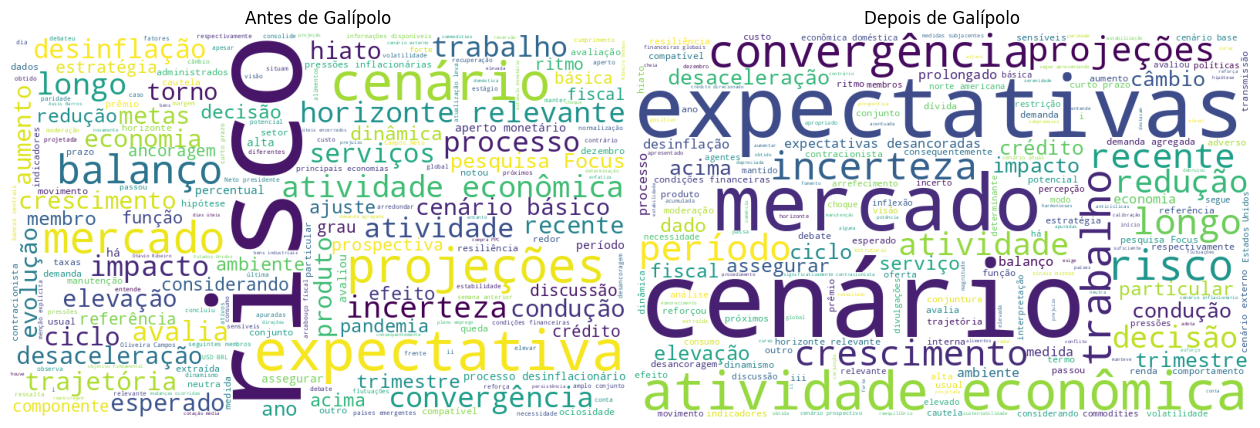

In [ ]:
corte = pd.Timestamp("2025-01-01")
dados['data'] = pd.to_datetime(dados['data'], format="%d/%m/%Y")

dados_antes = dados[dados['data'] < corte]
dados_depois = dados[dados['data'] >= corte]

texto_antes = ' '.join(dados_antes['texto'].dropna().astype(str))
wc_antes = WordCloud(stopwords=stopw, width=800, height=500, background_color='white').generate(texto_antes)

texto_depois = ' '.join(dados_depois['texto'].dropna().astype(str))
wc_depois = WordCloud(stopwords=stopw, width=800, height=500, background_color='white').generate(texto_depois)


fig, axes = plt.subplots(1,2,figsize=(16,10), gridspec_kw={'wspace':0.01})

axes[0].imshow(wc_antes)
axes[0].axis('off')
axes[0].set_title("Antes de Galípolo")

axes[1].imshow(wc_depois)
axes[1].axis('off')
axes[1].set_title("Depois de Galípolo")

É notável que a palavra que mais chama a atenção, antes da posse de Galípolo, é "risco", enquanto após sua posse se divide entre "expectativas", "mercado" e "cenário".

### Tokenização e lemmetização - testando se há diferença estatística entre as direções

Vamos agora, lemmetizar as palavras, criar token para elas e, com isso, poder testar se há alguma diferença estatística entre o BACEN sendo dirigido antes de Gabriel Galípolo e depois dele.

In [ ]:
reg = re.compile("[^A-zÀ-ú0-9]+")

def lemmetizar(texto):
    doc = reg.sub(' ',texto).lower()
    doc = nlp(doc)
    return [token.lemma_ for token in doc if not token.is_stop and not token.is_space and token.is_alpha]

lemmetizar("O rato roeu a roupa do rei de roma")

['rato', 'roeu', 'roupa', 'rei', 'Roma']

Com a função de lemmetização introduzida, iremos a partir de agora fazer o teste pra ver quais palavras sofreram mudança estatística significativa.

Utilizaremos o teste U de Mann–Whitney. Ele funcionará da seguinte forma:
Teremos as 2 distribuições de frequências relativas: antes e depois de Galípolo. 

O que o modelo fará é testar se a distribuição das frequências relativas (isto é, o % da frequência de uma palavra qualquer sobre todas as palavras) muda entre as distribuições.

Ou seja, testa a hipótese nula de que as distribuições de probabilidade são idênticas, ou que as duas amostras vêm da mesma distribuição

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import normalize
import pandas as pd
from statsmodels.stats.multitest import multipletests

# desabilitei algumas funções desnecessárias para o Pipeline do Spacy

desabilitar = ["parser", "ner", "tagger", "entity_linker", "entity_ruler", "textcat", "textcat_multilabel", "trainable_lemmatizer",
              "senter", "sentencizer", "transformer"]

# vamos compilar logo o regex para que ele nao fique rodando sobre todas as linhas dos dados
reg = re.compile("[^A-zÀ-ú0-9]+")


dados_antes.loc[:,'corpus'] = dados_antes['texto'].apply(lambda x:reg.sub(' ', x).lower())
dados_depois.loc[:,'corpus'] = dados_depois['texto'].apply(lambda x:reg.sub(' ', x).lower())

textos_antes = []
textos_depois = []

# aqui é feita a lemmetização pra cada linha do DataFrame

for doc in nlp.pipe(dados_antes['corpus']):
    retorno = " ".join([token.lemma_ for token in doc if not token.is_stop and token.is_alpha])
    textos_antes.append(retorno)
for doc in nlp.pipe(dados_depois['corpus']):
    retorno = " ".join([token.lemma_ for token in doc if not token.is_stop and token.is_alpha])
    textos_depois.append(retorno)

todos_textos  = textos_antes + textos_depois

# Essa é a etapa de vetorização

# Abaixo ele irá contar quantas vezes a palavra aparece em cada ata
vectorizer = CountVectorizer(min_df=25)  # ignora palavras que aparecem menos de 25 vezes
contagens = vectorizer.fit_transform(todos_textos)

vocab = vectorizer.get_feature_names_out()
n_antes = len(textos_antes)

# normalizar pra pegar a frequencia relativa das palavras na ata
matriz_freq = normalize(contagens, norm='l1').toarray()

# Separa as matrizes entre antes de Galípolo e depois
matriz_antes  = matriz_freq[:n_antes]
matriz_depois = matriz_freq[n_antes:]

# Mann-Whitney por palavra
resultados = []
for i, palavra in enumerate(vocab):
    a = matriz_antes[:, i]
    b = matriz_depois[:, i]
    
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    resultados.append({
        'palavra':          palavra,
        'freq_medio_antes':  a.mean(),
        'freq_medio_depois': b.mean(),
        'variacao':           b.mean() - a.mean(),
        'p_valor':            p
    })

df_resultado = pd.DataFrame(resultados).sort_values('p_valor')

# correção de FDR pra evitar muitos falsos positivos (aqui eu pedi ajuda ao Claude rs)
df_resultado['p_adjust'] = multipletests(
    df_resultado['p_valor'],
    method='fdr_bh'
)[1]

df_resultado['significativo'] = (
    df_resultado['p_adjust'] < 0.05
)

df_resultado[df_resultado['significativo']]

,palavra,freq_medio_antes,freq_medio_depois,variacao,p_valor,p_adjust,significativo
52,campos,0.001275,0.000000,-0.001275,5.906837e-07,0.000034,True
224,oliveira,0.001275,0.000000,-0.001275,5.906837e-07,0.000034,True
214,neto,0.001275,0.000000,-0.001275,5.906837e-07,0.000034,True
288,roberto,0.001275,0.000000,-0.001275,5.906837e-07,0.000034,True
308,torno,0.003999,0.000100,-0.003898,6.157366e-07,0.000034,True
...,...,...,...,...,...,...,...
56,central,0.002302,0.001161,-0.001141,1.310109e-02,0.033748,True
23,aperto,0.003732,0.001335,-0.002397,1.578714e-02,0.040345,True
48,brasileiro,0.001253,0.000284,-0.000969,1.639092e-02,0.041558,True
95,debater,0.001588,0.000533,-0.001055,1.863485e-02,0.046878,True


Acima temos o DataFrame com as palavras que registraram diferença estatisticamente significante entre as distribuições.

Selecionamos apenas onde p-valor < 0,05, isto é, podemos rejeitar a hipótese nula de que as amostras venham da mesma distribuição.

Podemos ver algo interessante: diretores que não participaram mais após a posse de Galípolo tiveram seus nomes detectados pelo modelo. O que faz sentido: não é esperado que "campos", "neto", "oliveira", "roberto" esteja em uma ata se ele não é mais o presidente do Banco Central após a posse de Galípolo.

Alguns comentários:

_atividade_, _trabalho_ e _demanda_ apresentaram aumento estatisticamente significante em sua frequência. O que é esperado tendo em vista um crescimento do PIB mais estável e positivo, sobretudo após o início do governo Lula em 2022

Enquanto o termo _pandemia_ teve movimento oposto, desaparecendo completamente nas atas do período de presidência de Gabriel Galípolo, enquanto teve uma frequência maior enquanto Roberto Campos Neto era o presidente da autarquia. Outro termo que aparece em queda é o _arcabouço_, que dominou a pauta fiscal até sua aprovação em agosto de 2023, não a toa outro termo que entra em queda é _ajuste_, provavelmente vindo de _ajuste fiscal_.

Certamente não é uma análise exaustiva entre as direções, mas serve para contribuir para o debate e também para o uso de programação na análise econômica.

Espero ter contribuido com meus conhecimentos e estou sempre aberto a sugestões.